# [IAPR][iapr]: Project - UNO cards segmentation

**Group ID:** 14

**Author 1 (sciper):** Mario Fernández Blanco (412680)  
**Author 2 (sciper):** Mahdi Fourati (313078)   
**Author 3 (sciper):** Antonin Médéric Hudry (341945)

---

### Imports

In [1]:
from utils import *
from dataset_creator import *
import cv2
import pandas as pd
import numpy as np
import os
import os.path as op
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path

In [2]:
REFERENCES_PATH = Path('D:/pattern_analysis/group14_iapr454/project/reference_images')
SEGMENTED_REFERENCE_PATH = Path('D:/pattern_analysis/group14_iapr454/project/segmented_reference_images')

### Introduction

For this project, we decided to use classical methods of segmentation, mainly using fourier descriptors as a mean to classify cards, and morphology to classify . We created an extended reference dataset, by manually segmenting the reference images, creating rotated versions of these references, creating the contours, curating them manually and using the left over.

From these newly created reference images, we extracted the Fourier descriptors by finding the contours in the image, filtering by size, then interpolating these contours and creating a signal for each filtered contour defined by: $u = x + jy$

With the descriptors, we decided to classify each contour first via a KNN, and then filtering the results further for special cases, and when the contour is too far from any neighbor.

Three main problem: 
- Holes inside 6, 8, 9 cards (the center numbers not the contours) are detected as zeros, so we had to filter by distance, which isn't a clean way to do it, and can sometimes remove a zero in the prediction, when it was in fact a true label
- skip, zeros and wilds are assimilitad similarly, with zero being prevalent
- 6 and 9 are the 180° spin of each other, so there was no clear way to discriminate both. Attempts were made but unsucessful, so we defaulted to assign everything to 'six'

---

### Data extension

The idea here was to simply manually segment all of the reference images to frame properly each card (note that the blue nine is missing, because one corner was damaged unfortunately and so was disrupting the contour detection):

In [3]:
reference_folder = r"reference_images"

references = []
for path in glob(os.path.join(reference_folder, "*")):
    img = cv2.imread(path, cv2.IMREAD_COLOR_RGB)

    if img is not None:
        references.append(img)

In [4]:
r0 = references[0]

one_two_three = r0[600:2490, 1250:2960]

one   = one_two_three[1240:]
two   = one_two_three[640:1270]
three = one_two_three[10:650]

one_yellow, one_red, one_blue, one_green = one[20:,60:400], one[40:,490:840], one[20:-20,940:1290], one[20:-20,1350:-10]
two_yellow, two_red, two_blue, two_green = two[10:,50:390], two[10:,470:820], two[:-20,900:1250], two[:-20,1290:-10]
three_yellow, three_red, three_blue, three_green = three[20:,20:380], three[20:,430:850], three[20:-10,890:1240], three[:-20,1310:-30]

In [5]:
r1 = references[1]

four_five_six = r1[550:2470,1470:3400]

four = four_five_six[1280:]
five = four_five_six[740:1320]
six  = four_five_six[20:700]

four_yellow, four_red, four_blue, four_green = four[40:-20,160:560], four[30:-10,560:950], four[30:-10,1050:1450], four[60:-10,1530:-10]
five_yellow, five_red, five_blue, five_green = five[20:-20,100:460], five[10:-20,550:910], five[10:,1010:1400], five[10:-20,1500:-40]
six_yellow, six_red, six_blue, six_green = six[90:-20,50:420], six[70:-20,490:890], six[60:-60,1000:1360], six[:-70,1450:-70]

In [6]:
r2 = references[2]

seven_eight_nine = r2[600:2550,1700:3680]

seven = seven_eight_nine[1300:]
eight = seven_eight_nine[720:1300]
nine  = seven_eight_nine[30:680]

wild     = r2[1760:2350,1200:1600]
plus4    = r2[880:1520, 1130:1530]

seven_yellow, seven_red, seven_blue, seven_green = seven[90:-20,170:550], seven[70:-30,630:1000], seven[30:-20,1040:1450], seven[30:-70,1550:-60]
eight_yellow, eight_red, eight_blue, eight_green = eight[40:,110:470], eight[20:-20,560:920], eight[30:-10,1020:1380], eight[10:-20,1530:-90]
nine_yellow, nine_red, nine_blue, nine_green = nine[60:-30,40:400], nine[:-50,520:950], nine[40:,1040:1470], nine[:-60,1550:-10]

In [7]:
r3 = references[3]

plus2s   = r3[1700:2300, 100:1800]
reverses = r3[170:920, 1680:3500]
skips    = r3[880:1630, 1730:3670]
zeros    = r3[1570:2270, 1870:3680]

plus2_yellow, plus2_blue, plus2_red, plus2_green = plus2s[:,:400], plus2s[:,450:850], plus2s[:,850:1250], plus2s[:,1250:]
reverse_yellow, reverse_red, reverse_blue, reverse_green = reverses[150:,:400], reverses[100:-30,470:870], reverses[:650,930:1400], reverses[40:650,1420:]
skip_yellow, skip_red, skip_blue, skip_green = skips[140:,50:480], skips[120:-30,470:880], skips[50:700,890:1350], skips[:650,1430:1890]
zero_yellow, zero_red, zero_blue, zero_green = zeros[50:-10,:430], zeros[40:-50,450:870], zeros[10:630,910:1330], zeros[:620,1350:1790]

In [8]:
image_groups = {
    "zero": [zero_blue, zero_green, zero_red, zero_yellow],
    "one": [one_blue, one_green, one_red, one_yellow],
    "two": [two_blue, two_green, two_red, two_yellow],
    "three": [three_blue, three_green, three_red, three_yellow],
    "four": [four_blue, four_green, four_red, four_yellow],
    "five": [five_blue, five_green, five_red, five_yellow],
    "six-nine": [six_blue, six_green, six_red, six_yellow, nine_green, nine_red, nine_yellow],
    "seven": [seven_blue, seven_green, seven_red, seven_yellow],
    "eight": [eight_blue, eight_green, eight_red, eight_yellow],
    "reverse": [reverse_blue, reverse_green, reverse_red, reverse_yellow],
    "skip": [skip_blue, skip_green, skip_red, skip_yellow],
    "plus": [plus2_blue, plus2_green, plus2_red, plus2_yellow, plus4],
    "wild": [wild],
}

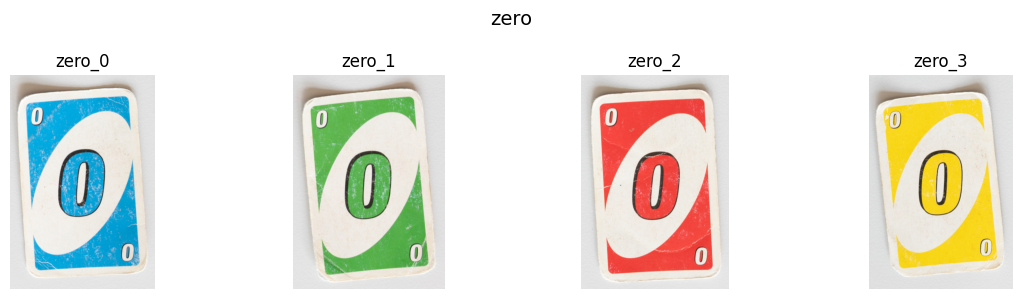

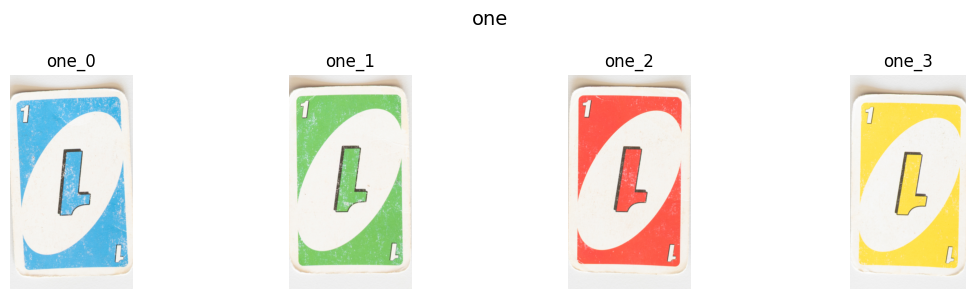

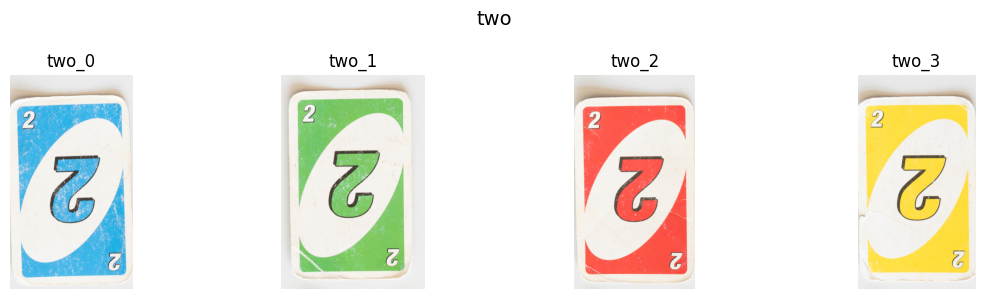

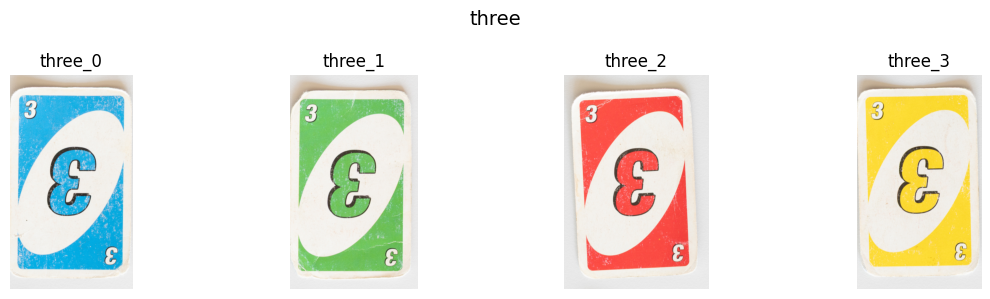

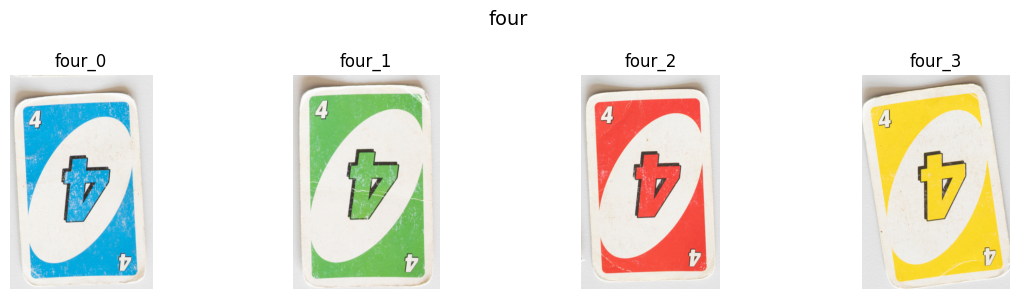

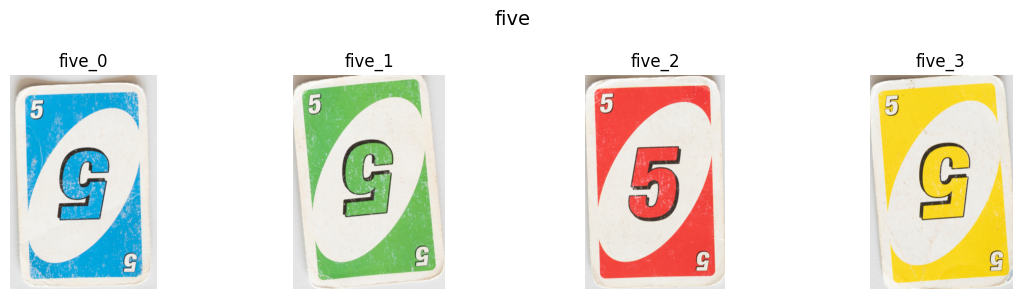

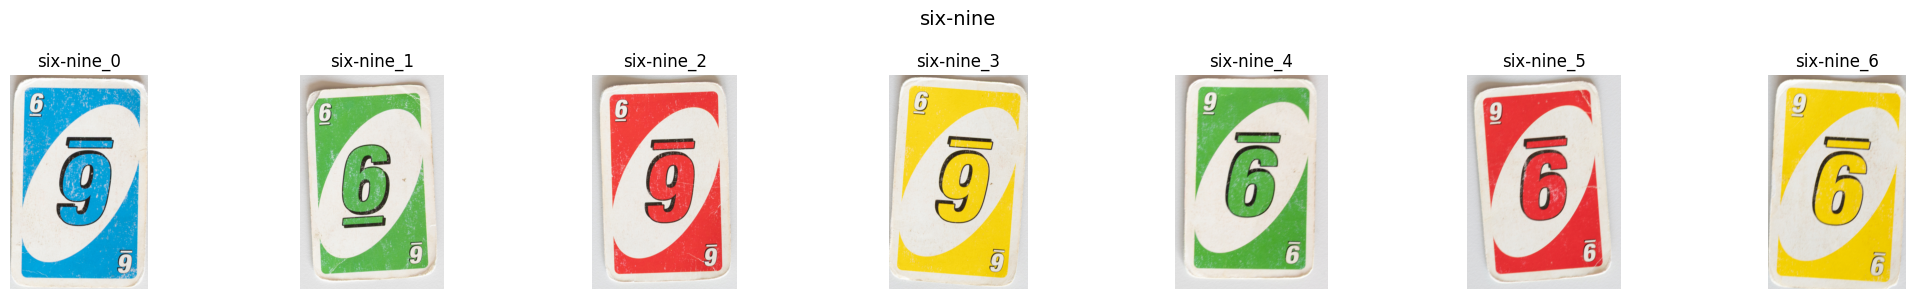

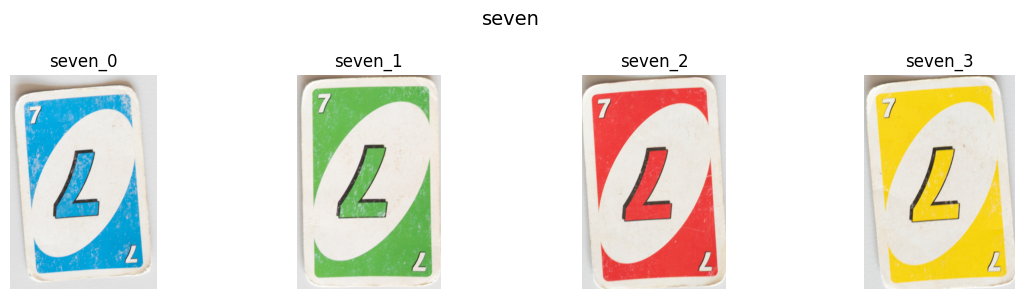

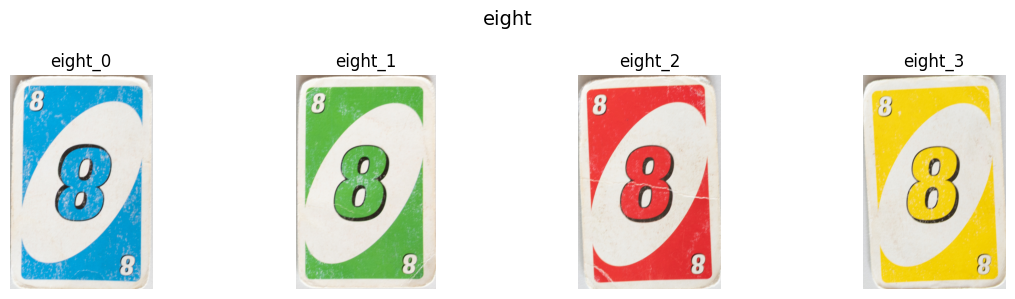

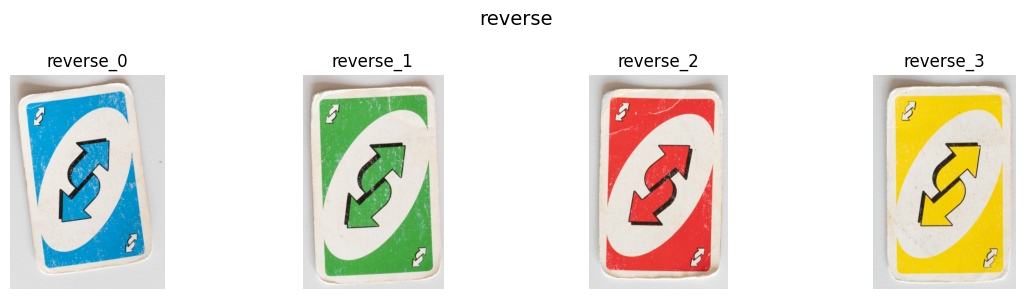

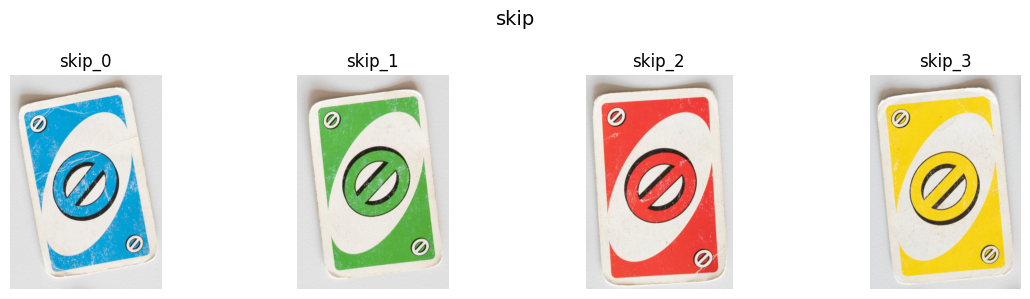

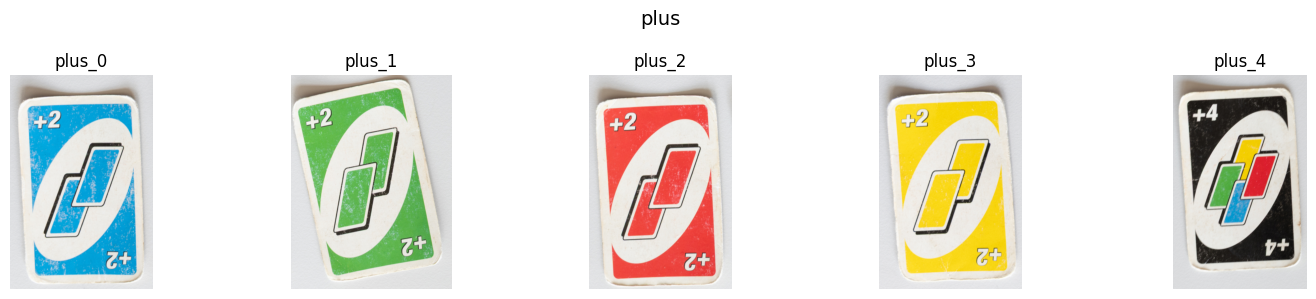

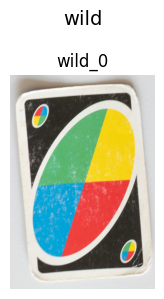

In [9]:
for label, imgs in image_groups.items():

    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=(3*n, 3))

    # if only one image (e.g. wild), axs is not a list → fix it
    if n == 1:
        axs = [axs]

    fig.suptitle(label, fontsize=14)

    for i, img in enumerate(imgs):
        axs[i].imshow(img)
        axs[i].set_title(f"{label}_{i}")
        axs[i].axis("off")

    plt.tight_layout()
    plt.show()

---

### Finding cards

The second task is to actually find the cards in the images. The simplest is to apply a threshold on RGB and HSV values.

For the white background image, the task is relatively easy, as we can just filter any pixel that is too white, which keeps most of the card information:

In [10]:
def card_only_filter_blank(img):
    return ((img[:,:,0] < 180) |
            (img[:,:,1] < 180) |
            (img[:,:,2] < 180))

For the background with the leaves, it was a bit more complicated, but we managed to find a good threshold on HSV and RGB without damaging the cards too much:

In [30]:
def card_only_filter_leaf(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    rgb_filtered = apply_rgb_threshold(img, r_range=(200,255), g_range=(200,255), b_range=(200,255)) # see utils
    hsv_filtered = (hsv[:,:,0]<25) | ((hsv[:,:,0]<170)&(hsv[:,:,0]>160))
    return rgb_filtered & hsv_filtered

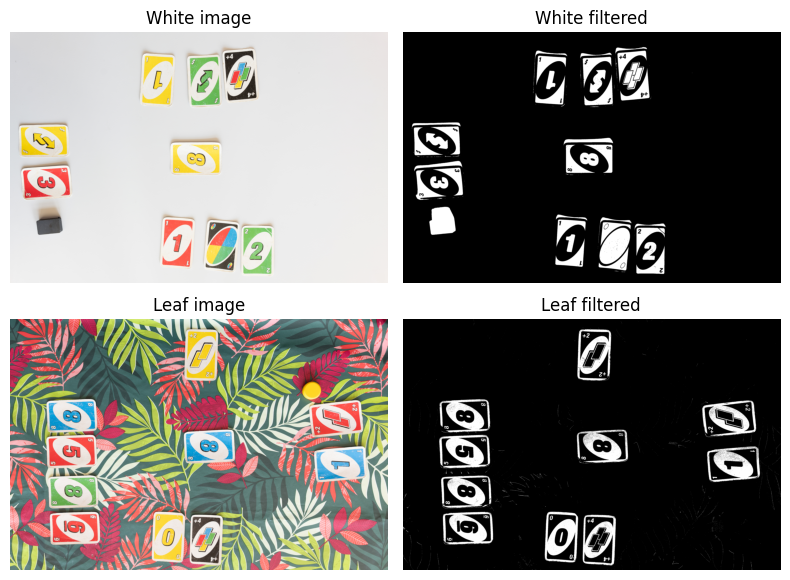

In [32]:
img_white_b = cv2.imread('train_images/L1000773.jpg')
img_leaf_b = cv2.imread('train_images/L1000907.jpg')

img_white = cv2.cvtColor(img_white_b, cv2.COLOR_BGR2RGB)
img_leaf = cv2.cvtColor(img_leaf_b, cv2.COLOR_BGR2RGB)

filtered_white = card_only_filter_blank(img_white_b)
filtered_leaf = card_only_filter_leaf(img_leaf)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].imshow(img_white)
axes[0,0].set_title("White image")

axes[0,1].imshow(filtered_white, cmap='gray')
axes[0,1].set_title("White filtered")

axes[1,0].imshow(img_leaf)
axes[1,0].set_title("Leaf image")

axes[1,1].imshow(filtered_leaf, cmap='gray')
axes[1,1].set_title("Leaf filtered")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

Notice that the filters act a bit differently, but this doesn't matter as long as we can see the corner digits.

---

### Fourier descriptors

As said in the introduction, the idea is to create a rotated dataset that will serve as a the neighborhood for the subsequent KNN (explained below):

In [13]:
datasets = {}
all_images = {}
all_contours = {}

for label, imgs in image_groups.items():

    rotated_imgs, contours, descriptors = build_rotated_descriptor_dataset(imgs, label, n_rotations=21, angle_step=9)

    all_images[label] = rotated_imgs
    all_contours[label] = contours

    datasets[label] = np.concatenate(descriptors, axis=0)

zero


d:\pattern_analysis\group14_iapr454\project\utils.py:330: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  gray = remove_small_objects(gray.astype(np.uint8), min_size=max_area)


one
two
three
four
five
six-nine
seven
eight
reverse
skip
plus
wild


Here we just applied what was done in lab 2 of this course, which includes interpolation and descriptor correction. Note that we made the descriptors invariant to rotation and position, but not to scaling as every card should have the same size in theory:

In [14]:
def fourier_descriptors(contours, n_samples=100, interpolation=True):
    """
    Compute translation and rotation invariant Fourier descriptors.
    
    Parameters
    ----------
    contours : list of (K,2) arrays
    n_samples : int
    interpolation : bool

    Returns
    -------
    descriptors : (N, n_samples-1)
        Translation + rotation invariant descriptors.

    centers : (N, 2)
        Contour centroids.

    rotations : (N,)
        Dominant contour orientation in radians.
    """

    descriptors = []
    centers = []
    rotations = []

    for contour in contours:

        contour = np.asarray(contour.squeeze(), dtype=np.float64)
        
        d = np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1))
        t = np.concatenate([[0], np.cumsum(d)])

        t_new = np.linspace(0, t[-1], n_samples)
        x = np.interp(t_new, t, contour[:, 0])
        y = np.interp(t_new, t, contour[:, 1])

        contour = np.stack([x, y], axis=1)
        
        center = contour.mean(axis=0)
        centers.append(center)

        z = contour[:, 0] + 1j * contour[:, 1]
        fd = np.fft.fft(z)
        fd[0] = 0

        rotation = np.angle(fd[1])
        rotations.append(rotation)
        fd *= np.exp(-1j * rotation)
        descriptors.append(np.abs(fd[1:]))

    return (
        np.array(descriptors),
        np.array(centers),
        np.array(rotations)
    )

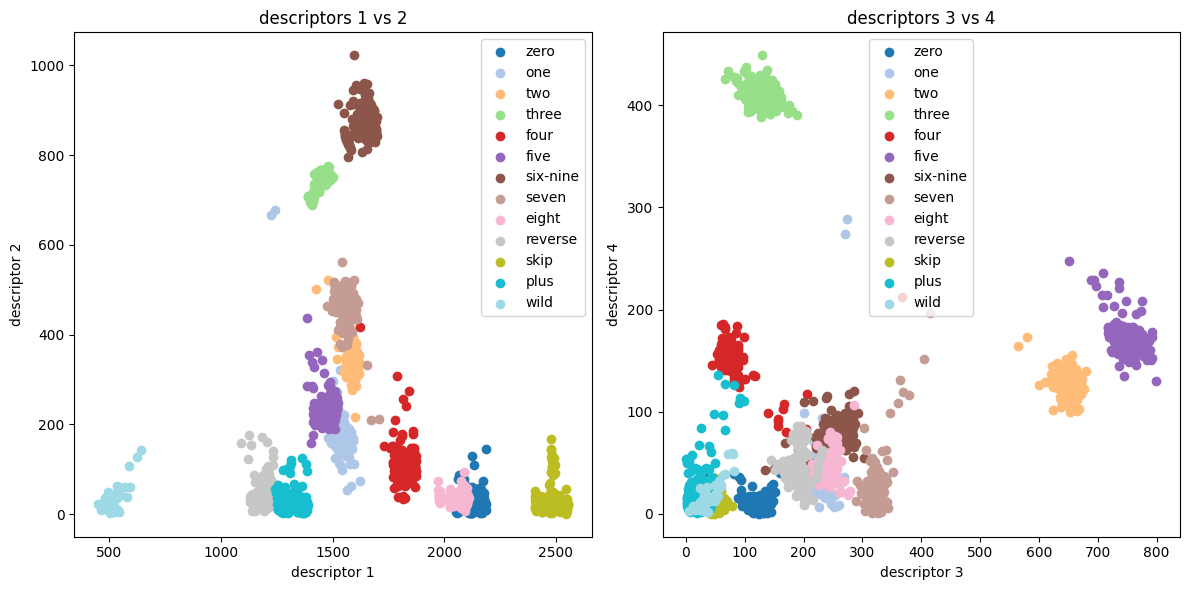

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = plt.cm.tab20(np.linspace(0, 1, len(datasets)))

for (label, data), color in zip(datasets.items(), colors):

    axes[0].scatter(
        data[:, 0],
        data[:, 1],
        label=label,
        color=color
    )

    axes[1].scatter(
        data[:, 2],
        data[:, 3],
        label=label,
        color=color
    )

axes[0].set_title("descriptors 1 vs 2")
axes[1].set_title("descriptors 3 vs 4")
axes[0].set_xlabel('descriptor 1')
axes[0].set_ylabel('descriptor 2')
axes[1].set_xlabel('descriptor 3')
axes[1].set_ylabel('descriptor 4')

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

As you can see, the cloud of point is already very separable with only four points. In the dataset, we are using 100 fourier descriptors, so it should already give a good classifier.

---

### Cropping contour and finding colors

In order to find the color, 



----

### KNN Classifier

As seen before, we extended the dataset to get only cropped reference images, as well as rotated version of these reference. This allowed us to get a pretty large data cloud. What is good with UNO cards is that the shape of the contours shouldn't change much (apart from slight camera angle variation and scale), which means that every contour we detect should be relatively close to the cloud we generated.

Our idea is to use this fourier descriptors cloud as a reference, and classify contours based on their distance to these points. This is basically the definition of a KNN classifier. Since our data point types are inhomogenous in number (due to data curation and number of available samples (e.g. 4 for colored card and one for wild and draw 4)), the fairest and also what was found more effective is using a single nearest neighbor. This usually leads to overfitting, but again, the shape of our contour shouldn't differ by much between cards, so overfitting is irrelevant here. Although we can have detected contours that correspond to none of the card. In this case, we apply a rejection threshold based on distance. So a point that is too far from everything should be rejected.

We found that a rejection threshold of ~10 is sufficient

below is the code for the classifier and a test on one image:

In [16]:
class FourierDiscriminator:

    def __init__(
        self,
        n_neighbors=3,
        rejection_threshold=2.0
    ):

        self.scaler = StandardScaler()

        self.knn = KNeighborsClassifier(
            n_neighbors=n_neighbors
        )

        self.rejection_threshold = rejection_threshold

    def fit(
        self,
        datasets,
        test_size=0.2,
        random_state=42,
        verbose = False
    ):

        X, y = build_classifier_dataset(datasets)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=random_state
        )
        X_train = self.scaler.fit_transform(X_train)
        X_test = self.scaler.transform(X_test)

        self.knn.fit(X_train, y_train)

        y_pred = self.knn.predict(X_test)
        if verbose:
            print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
            print(f"Macro F1 : {f1_score(y_test, y_pred, average='macro'):.4f}\n")
            print(classification_report(y_test, y_pred))

    def predict(self, descriptor):

        descriptor = np.asarray(descriptor).reshape(1, -1)
        descriptor = self.scaler.transform(descriptor)

        distances, _ = self.knn.kneighbors(descriptor)
        mean_distance = distances.mean()

        if mean_distance > self.rejection_threshold:
            return "None", mean_distance

        prediction = self.knn.predict(descriptor)[0]

        return prediction, mean_distance

In [17]:
classifier = FourierDiscriminator(n_neighbors=1, rejection_threshold=10)
classifier.fit(datasets)

c:\Users\hudry\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\hudry\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hudry\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hudry\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "

In [ ]:
img_test = cv2.imread('train_images/L1000772.jpg', cv2.IMREAD_COLOR_RGB)
contours, _ = detect_number_contours(card_only_filter_blank(img_test).astype(np.uint8))
descriptors, centers, angles = fourier_descriptors(contours)

card_types = []
for idx, descriptor in enumerate(descriptors):

    descriptor = np.asarray(descriptor).flatten()
    card_type, dist = classifier.predict(descriptor)
    card_types.append(card_type)
print(card_types)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\contours_new.cpp:335: error: (-2:Unspecified error) in function 'class std::shared_ptr<struct ContourScanner_> __cdecl ContourScanner_::create(class cv::BlockStorage<class cv::Point_<int>,1024,0> &,class cv::BlockStorage<signed char,1024,0> &,class cv::Mat,int,int,class cv::Point_<int>)'
> Modes other than RETR_FLOODFILL and RETR_CCOMP support only CV_8UC1 images (expected: 'img.type() == CV_8UC1'), where
>     'img.type()' is 16 (CV_8UC3)
> must be equal to
>     'CV_8UC1' is 0 (CV_8UC1)
